In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

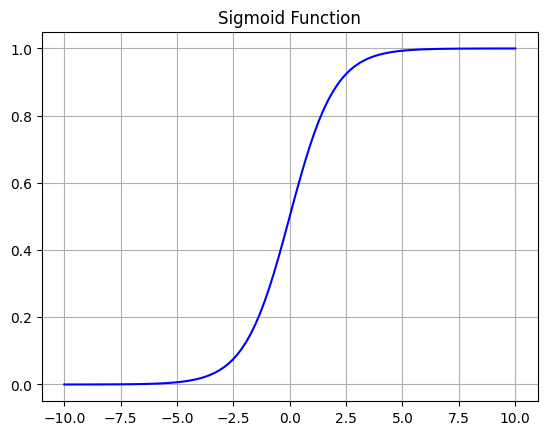

In [4]:
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z), label='Sigmoid', color='blue')
plt.title("Sigmoid Function")
plt.grid(True)

In [5]:
def compute_loss(y_true, y_pred):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    m = len(y_true)
    return (-1/m)*np.sum(y_true*np.log(y_pred) + (1 - y_true)*np.log(1-y_pred))

In [6]:
class LogisticRegression:
    def __init__(self, lr = 0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        for _ in range(self.epochs):
            z = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(z)
            self.losses.append(compute_loss(y, y_pred))
            dw = (1/m) * X.T @ (y_pred - y)
            db = (1/m) * np.sum(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [7]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = (iris.target == 0).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(lr=0.01, epochs=2000)
model.fit(X_train_scaled, y_train)

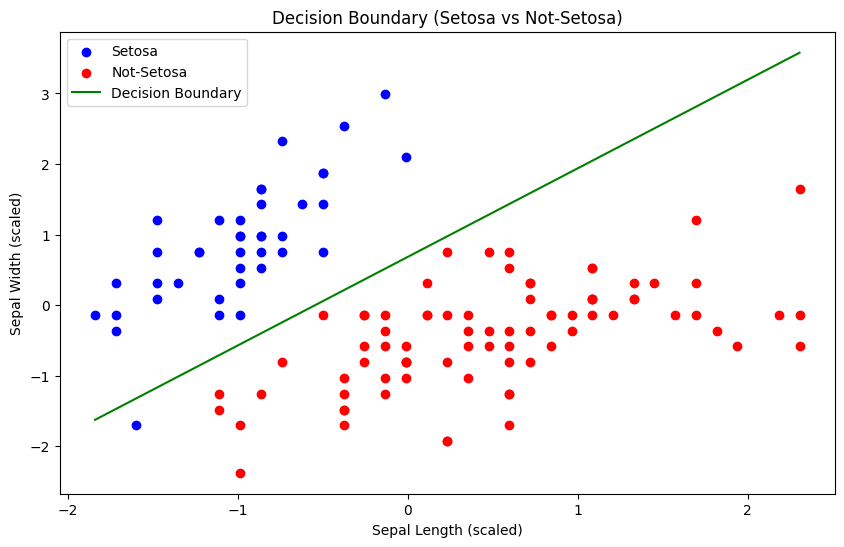

In [9]:
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(10, 6))
    plt.scatter(X[y==1][:,0], X[y==1][:,1], color='blue', label='Setosa')
    plt.scatter(X[y==0][:,0], X[y==0][:,1], color='red', label='Not-Setosa')
    
    x_values = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    y_values = -(model.weights[0] * x_values + model.bias) / model.weights[1]
    
    plt.plot(x_values, y_values, label='Decision Boundary', color='green')
    plt.xlabel('Sepal Length (scaled)')
    plt.ylabel('Sepal Width (scaled)')
    plt.legend()
    plt.title("Decision Boundary (Setosa vs Not-Setosa)")
    plt.show()

plot_decision_boundary(X_train_scaled, y_train, model)


In [ ]:
y_pred = model.predict(X_test_scaled)

def get_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    confusion_matrix = np.array([[tn, fp], [fn, tp]])
    
    return accuracy, precision, recall, f1, confusion_matrix

acc, prec, rec, f1, cm = get_metrics(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Confusion Matrix:\n{cm}")